<a href="https://colab.research.google.com/github/Andrea-24744/Procesos-Est-casticos-/blob/main/MEDEL_actividad_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Descomposición canónica



> **Se tiene la siguiente matriz**





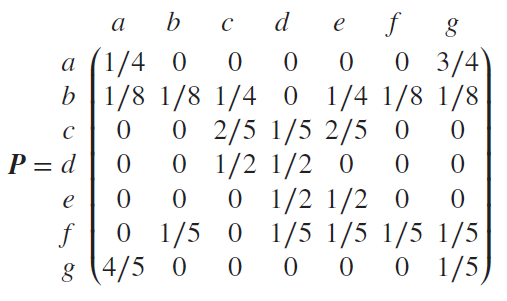

1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.

In [3]:
# La reescribimos en código
import sympy as sp
import networkx as nx

P = sp.Matrix([
    [1/4,0,0,0,0,0,3/4],
    [1/8,1/8,1/4,0,1/4,1/8,1/8],
    [0,0,2/5,1/5,2/5,0,0],
    [0,0,1/2,1/2,0,0,0],
    [0,0,0,1/2,1/2,0,0],
    [0,1/5,0,1/5,1/5,1/5,1/5],
    [4/5,0,0,0,0,0,1/5]
])
sp.pprint(P)

⎡0.25     0     0     0    0      0    0.75 ⎤
⎢                                           ⎥
⎢0.125  0.125  0.25   0   0.25  0.125  0.125⎥
⎢                                           ⎥
⎢  0      0    0.4   0.2  0.4     0      0  ⎥
⎢                                           ⎥
⎢  0      0    0.5   0.5   0      0      0  ⎥
⎢                                           ⎥
⎢  0      0     0    0.5  0.5     0      0  ⎥
⎢                                           ⎥
⎢  0     0.2    0    0.2  0.2    0.2    0.2 ⎥
⎢                                           ⎥
⎣ 0.8     0     0     0    0      0     0.2 ⎦


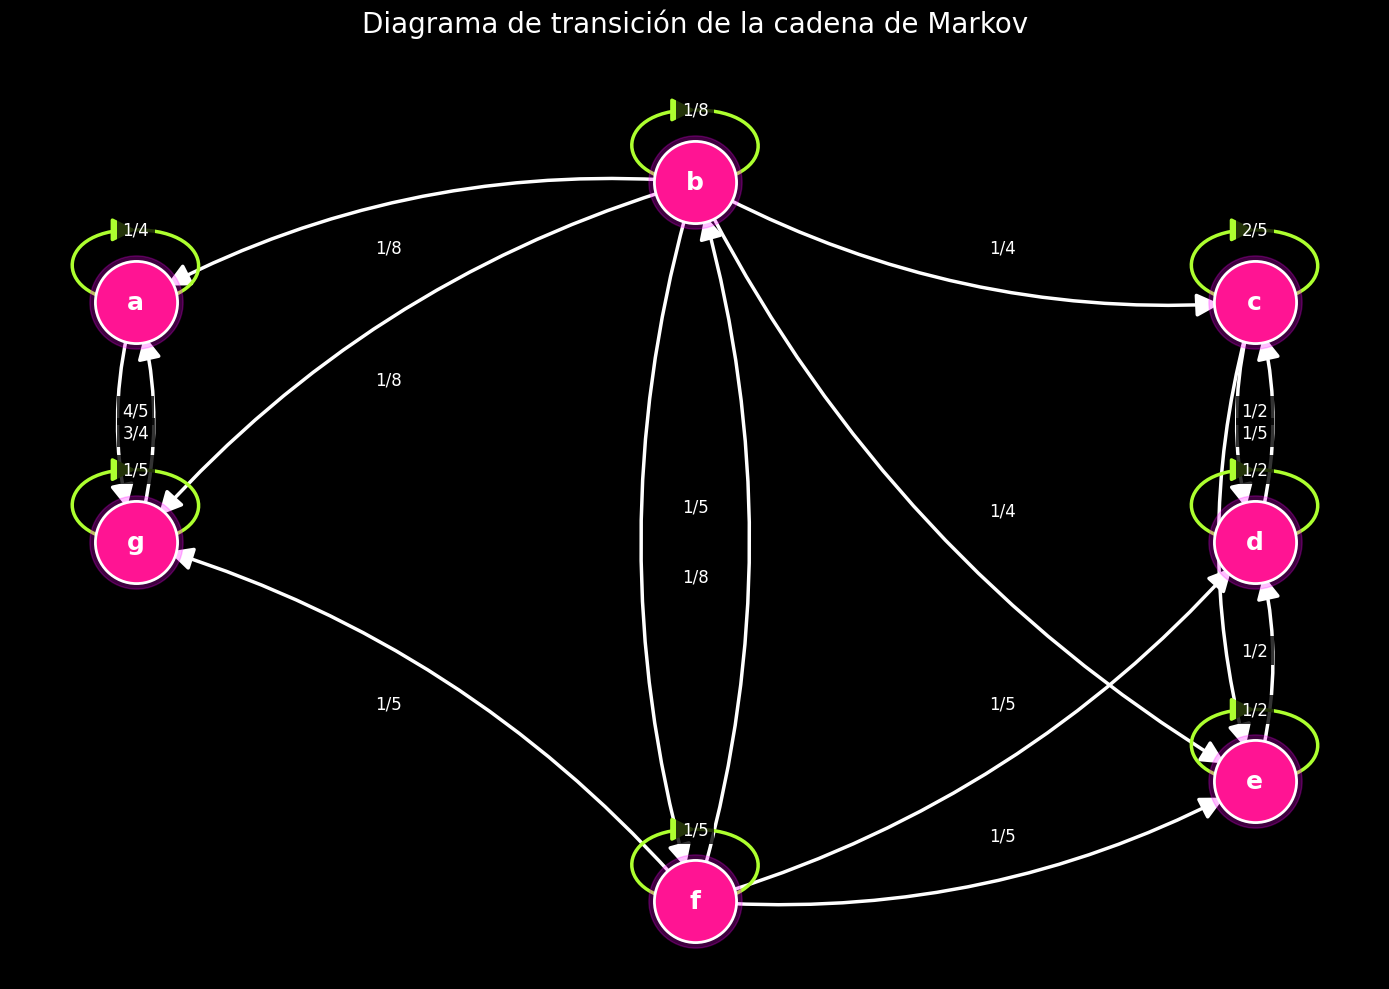

In [4]:

# Diagrama de transición de una cadena de Markov

import networkx as nx
import matplotlib.pyplot as plt
from sympy import Rational

# Colocamos nuestros estados
estados = ['a','b','c','d','e','f','g']


# Definimos la Matriz de transición (usando Rational de sympy),
# de manera que indiquemos cada una de las conecciones que tienen los nodos, es decir la comunicación del sistema

P = {
    'a': {'a': Rational(1,4), 'g': Rational(3,4)}, # comunicación de a --> g

    'b': {
        'a': Rational(1,8), # accesible de b --> a
        'b': Rational(1,8), # comunicación de b --> b
        'c': Rational(1,4), # accesible de b --> c
        'e': Rational(1,4), # accesible de b --> d
        'f': Rational(1,8), # accesible de b --> e
        'g': Rational(1,8)  # comunicación de b --> f
    },

    'c': {
        'c': Rational(2,5), # comunicación de c --> c
        'd': Rational(1,5), # comunicación de c --> d
        'e': Rational(2,5)  # comunicación de c --> e
    },

    'd': {
        'c': Rational(1,2), # comunicación de d --> c
        'd': Rational(1,2)  # comunicación de d --> d
    },

    'e': {
        'd': Rational(1,2), # comunicación de e --> d
        'e': Rational(1,2)  # comunicación de e --> e
    },

    'f': {
        'b': Rational(1,5), # comunicación de f --> b
        'd': Rational(1,5), # accesible de f --> d
        'e': Rational(1,5), # accesible de f --> e
        'f': Rational(1,5), # comunicación de f --> f
        'g': Rational(1,5)  # accesible de f --> g
    },

    'g': {
        'a': Rational(4,5),
        'g': Rational(1,5)
    }
}


# Creamos grafo dirigido
G = nx.DiGraph()

# Agregamos nodos
for estado in estados:
    G.add_node(estado)

# Agregamos aristas
for origen in P:
    for destino, prob in P[origen].items():
        G.add_edge(origen, destino, weight=str(prob))


# POSICIONES (esto evita que TODO salga amontonado)

pos = {
    'a': (-2, 2),
    'b': (0, 3),
    'c': (2, 2),
    'd': (2, 0),
    'e': (2, -2),
    'f': (0, -3),
    'g': (-2, 0)
}


# A mi gusto lo voy a imprimir

fig, ax = plt.subplots(figsize=(14,10))

# fondo negro
fig.patch.set_facecolor('black')
ax.set_facecolor('black')


# NODOS ROSA NEÓN
# brillo exterior
nx.draw_networkx_nodes(
    G,
    pos,
    node_color='#ff00ff',
    node_size=4500,
    alpha=0.25
)

# nodo principal
nx.draw_networkx_nodes(
    G,
    pos,
    node_color='deeppink',   # rosa neón
    node_size=3500,
    edgecolors='white',
    linewidths=2
)


# Etiquetas de los nodos

nx.draw_networkx_labels(
    G,
    pos,
    font_size=18,
    font_weight='bold',
    font_color='white'
)


# Separamos bucles("loops")
loops = [(u,v) for u,v in G.edges() if u == v]
normal = [(u,v) for u,v in G.edges() if u != v]


# Aristas normales (BLANCAS)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=normal,
    edge_color='white',
    arrows=True,
    arrowstyle='-|>',
    arrowsize=35,
    width=2.5,
    min_source_margin=25,
    min_target_margin=25,
    connectionstyle='arc3,rad=0.15'
)


# LOOPS ROJOS
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=loops,
    edge_color='greenyellow',
    width=2.5,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=35,
    min_source_margin=25,
    min_target_margin=25,
    connectionstyle='arc3,rad=0.4'
)


# Etiquetamos las probabilidades

edge_labels = {
    (u,v): d['weight']
    for u,v,d in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=12,
    font_color='white',
    label_pos=0.55,
    rotate=False,
    bbox=dict(
        facecolor='black',
        edgecolor='none',
        alpha=0.8
    )
)


# Graficamos

plt.title(
    "Diagrama de transición de la cadena de Markov",
    fontsize=20,
    color='white',
    pad=20
)

plt.axis('off')
plt.tight_layout()
plt.show()

2. Determine si la matriz tiene o no distribución límite.

In [5]:

# CLASES DE COMUNICACIÓN

def clases_comunicacion(P):
    import networkx as nx

    G = nx.DiGraph()

    for origen in P:
        for destino, prob in P[origen].items():
            if prob != 0:
                G.add_edge(origen, destino)

    return list(nx.strongly_connected_components(G))


clases = clases_comunicacion(P)

print("Clases de comunicación:")
print(clases)

Clases de comunicación:
[{'g', 'a'}, {'c', 'e', 'd'}, {'f', 'b'}]


In [6]:

# CLASIFICACIÓN DE ESTADOS

def es_cerrada(P, clase):
    for i in clase:
        for j, prob in P[i].items():
            if prob != 0 and j not in clase:
                return False
    return True

cerradas = []
transientes = []

for clase in clases:
    if es_cerrada(P, clase):
        cerradas.append(list(clase))
    else:
        transientes.extend(list(clase))

print("Clases cerradas / estados recurentes :", cerradas)
print("Estados transientes:", transientes)

Clases cerradas / estados recurentes : [['g', 'a'], ['c', 'e', 'd']]
Estados transientes: ['f', 'b']



---
Recordemos:

Una cadena de Markov tiene distribución límite única si:

1. es irreducible
2. es aperiódica
3. y positiva recurrente (regular)

Pero nuestra cadena NO es irreducible porque
está dividida en varias clases de comunicación.

Tenemos dos clases cerradas:

    C1 = {a,g}
    C2 = {c,d,e}

y estados transitorios:

    T = {b,f}

Por lo tanto, **la matriz completa NO tiene una única
distribución límite global.**
Sin embargo:

- ***cada clase cerrada sí posee su propia distribución límite.***
---



3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

In [7]:

# 3. DESCOMPOSICIÓN CANÓNICA


def descomposicion_canonica(P):

    # -------- GRAFO --------
    G = nx.DiGraph()

    for i in P:
        for j, prob in P[i].items():
            if prob != 0:
                G.add_edge(i, j)

    clases = list(nx.strongly_connected_components(G))

    # -------- CLASES CERRADAS --------
    def es_cerrada(clase):
        for i in clase:
            for j, prob in P[i].items():
                if prob != 0 and j not in clase:
                    return False
        return True

    cerradas = []
    transitorios = []

    for clase in clases:
        if es_cerrada(clase):
            cerradas.append(list(clase))
        else:
            transitorios.extend(list(clase))

    # -------- ORDEN CANÓNICO --------
    orden = transitorios + [i for clase in cerradas for i in clase]

    # -------- CONSTRUIR MATRIZ DESDE EL DICCIONARIO --------
    n = len(orden)
    P_canonica = sp.zeros(n)

    for i, origen in enumerate(orden):
        for j, destino in enumerate(orden):
            if destino in P[origen]:
                P_canonica[i, j] = P[origen][destino]

    # -------- BLOQUES --------
    t = len(transitorios)

    Q = P_canonica[:t, :t]
    R = P_canonica[:t, t:]
    S = P_canonica[t:, t:]

    return {
        "orden": orden,
        "P_canonica": P_canonica,
        "Q": Q,
        "R": R,
        "S": S,
        "transitorios": transitorios,
        "cerradas": cerradas
    }

resultado = descomposicion_canonica(P)

for k, v in resultado.items():
    print(f"\n{k}:")
    sp.pprint(v)


orden:
[f, b, g, a, c, e, d]

P_canonica:
⎡1/5  1/5  1/5   0    0   1/5  1/5⎤
⎢                                 ⎥
⎢1/8  1/8  1/8  1/8  1/4  1/4   0 ⎥
⎢                                 ⎥
⎢ 0    0   1/5  4/5   0    0    0 ⎥
⎢                                 ⎥
⎢ 0    0   3/4  1/4   0    0    0 ⎥
⎢                                 ⎥
⎢ 0    0    0    0   2/5  2/5  1/5⎥
⎢                                 ⎥
⎢ 0    0    0    0    0   1/2  1/2⎥
⎢                                 ⎥
⎣ 0    0    0    0   1/2   0   1/2⎦

Q:
⎡1/5  1/5⎤
⎢        ⎥
⎣1/8  1/8⎦

R:
⎡1/5   0    0   1/5  1/5⎤
⎢                       ⎥
⎣1/8  1/8  1/4  1/4   0 ⎦

S:
⎡1/5  4/5   0    0    0 ⎤
⎢                       ⎥
⎢3/4  1/4   0    0    0 ⎥
⎢                       ⎥
⎢ 0    0   2/5  2/5  1/5⎥
⎢                       ⎥
⎢ 0    0    0   1/2  1/2⎥
⎢                       ⎥
⎣ 0    0   1/2   0   1/2⎦

transitorios:
[f, b]

cerradas:
[[g, a], [c, e, d]]


In [8]:

# POTENCIA N-ÉSIMA
n = 50 # lo suficientemente grande
Pn = resultado["P_canonica"]**n

Pn_redondeada = Pn.copy()

filas, cols = Pn.shape

for i in range(filas):
    for j in range(cols):
        Pn_redondeada[i, j] = round(float(Pn[i, j]), 2)

print(f"P^{n}:\n")
sp.pprint(Pn_redondeada)


P^50:

⎡0  0  0.16  0.17  0.22  0.18  0.27⎤
⎢                                  ⎥
⎢0  0  0.16  0.17  0.22  0.18  0.27⎥
⎢                                  ⎥
⎢0  0  0.48  0.52   0     0     0  ⎥
⎢                                  ⎥
⎢0  0  0.48  0.52   0     0     0  ⎥
⎢                                  ⎥
⎢0  0   0     0    0.33  0.27  0.4 ⎥
⎢                                  ⎥
⎢0  0   0     0    0.33  0.27  0.4 ⎥
⎢                                  ⎥
⎣0  0   0     0    0.33  0.27  0.4 ⎦


In [9]:

# DISTRIBUCIONES LÍMITE

"""
Clase cerrada 1:
{a,g}
"""

C1 = sp.Matrix([
    [sp.Rational(1,4), sp.Rational(3,4)],
    [sp.Rational(4,5), sp.Rational(1,5)]
])

print("Submatriz clase {a,g}:\n")
sp.pprint(C1)

# distribución estacionaria

pi1 = sp.symbols('p1:3')

eqs1 = [
    sp.Eq(pi1[0]/4 + 4*pi1[1]/5, pi1[0]),
    sp.Eq(3*pi1[0]/4 + pi1[1]/5, pi1[1]),
    sp.Eq(pi1[0] + pi1[1], 1)
]

sol1 = sp.solve(eqs1, pi1)

print("\nDistribución límite clase {a,g}:")
print(sol1)

Submatriz clase {a,g}:

⎡1/4  3/4⎤
⎢        ⎥
⎣4/5  1/5⎦

Distribución límite clase {a,g}:
{p1: 16/31, p2: 15/31}


In [10]:

# CLASE {c,d,e}


C2 = sp.Matrix([
    [sp.Rational(2,5), sp.Rational(1,5), sp.Rational(2,5)],
    [sp.Rational(1,2), sp.Rational(1,2), 0],
    [0, sp.Rational(1,2), sp.Rational(1,2)]
])

print("Submatriz clase {c,d,e}:\n")
sp.pprint(C2)

p1,p2,p3 = sp.symbols('p1 p2 p3')

eqs2 = [

    sp.Eq(
        sp.Rational(2,5)*p1 + sp.Rational(1,2)*p2,
        p1
    ),

    sp.Eq(
        sp.Rational(1,5)*p1 +
        sp.Rational(1,2)*p2 +
        sp.Rational(1,2)*p3,
        p2
    ),

    sp.Eq(
        sp.Rational(2,5)*p1 +
        sp.Rational(1,2)*p3,
        p3
    ),

    sp.Eq(p1+p2+p3,1)
]

sol2 = sp.solve(eqs2,[p1,p2,p3])

print("\nDistribución límite clase {c,d,e}:")
print(sol2)

Submatriz clase {c,d,e}:

⎡2/5  1/5  2/5⎤
⎢             ⎥
⎢1/2  1/2   0 ⎥
⎢             ⎥
⎣ 0   1/2  1/2⎦

Distribución límite clase {c,d,e}:
{p1: 1/3, p2: 2/5, p3: 4/15}


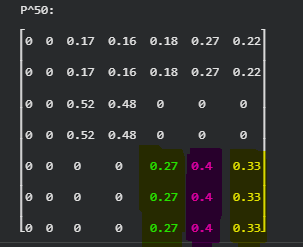

La matriz en forma canónica queda dada por:

$$P= \begin{pmatrix}
    Q & R \\
    0 & C
\end{pmatrix}$$

donde:

* **Q** corresponde a las transiciones entre estados transitorios,
* **R** representa las transiciones de estados transitorios hacia clases recurrentes
* **C** contiene las submatrices asociadas a las clases cerradas recurrentes.

Al calcular:

$$\lim_{n \to \infty} P^n$$

se observa que la parte correspondiente a $Q^n$ tiende a cero, debido a que los estados transitorios eventualmente abandonan dicha región.

Además, las submatrices recurrentes contenidas en $C$ convergen a matrices cuyas filas coinciden con sus respectivas distribuciones estacionarias.

En particular:

* la submatriz asociada a la clase recurrente ${a,g}$ converge a una matriz cuyas filas son:
$$\left( \frac{16}{31}, \frac{15}{31} \right) \quad \approx \quad (0.516,0.484) $$
* mientras que la submatriz asociada a ${c,d,e}$ converge a una matriz cuyas filas corresponden a:
$$\left( \frac{1}{3}, \frac{2}{5}, \frac{4}{15} \right) \quad \approx \quad(0.333,0.4, 0.267)$$

**Por lo tanto, el comportamiento límite de la cadena está determinado por las clases recurrentes cerradas y sus distribuciones estacionarias asociadas.**


4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.



In [16]:

# DESCOMPOSICIÓN CANÓNICA AUTOMÁTICA

import networkx as nx
import sympy as sp

def descomposicion_canonica(P):



    # crear grafo dirigido

    G = nx.DiGraph()

    for i in P:

        for j in P[i]:

            if P[i][j] != 0:

                G.add_edge(i,j)


    # componentes fuertemente conexas
    clases = list(nx.strongly_connected_components(G))

    print("Clases de comunicación:\n")

    for c in clases:
        print(c)


    # detectar clases cerradas

    cerradas = []

    transitorios = []

    for clase in clases:

        cerrada = True

        for nodo in clase:

            for vecino in G.successors(nodo):

                if vecino not in clase:

                    cerrada = False

        if cerrada:

            cerradas.append(clase)

        else:

            transitorios.extend(clase)

    print("\nClases cerradas:\n")

    for c in cerradas:
        print(c)

    print("\nEstados transitorios:\n")
    print(transitorios)


    # orden canónico

    orden = transitorios[:]

    for c in cerradas:

        orden.extend(list(c))

    print("\nOrden canónico:\n")
    print(orden)


    # construir matriz

    matriz = []

    for i in orden:

        fila = []

        for j in orden:

            if j in P[i]:

                fila.append(P[i][j])

            else:

                fila.append(0)

        matriz.append(fila)

    M = sp.Matrix(matriz)

    print("\nMatriz canónica:\n")

    sp.pprint(M)

    # MATRICES POR BLOQUES
    t = len(transitorios)

    # Q -> transitorios a transitorios
    Q = M[:t,:t]

    # R -> transitorios a recurrentes
    R = M[:t,t:]

    # C -> recurrentes
    C = M[t:,t:]

    print("\nMatriz Q:\n")
    sp.pprint(Q)

    print("\nMatriz R:\n")
    sp.pprint(R)

    print("\nMatriz C:\n")
    sp.pprint(C)

    return M

In [18]:

# Ejecución del programa
M = descomposicion_canonica(P)

Clases de comunicación:

{'g', 'a'}
{'c', 'e', 'd'}
{'f', 'b'}

Clases cerradas:

{'g', 'a'}
{'c', 'e', 'd'}

Estados transitorios:

['f', 'b']

Orden canónico:

['f', 'b', 'g', 'a', 'c', 'e', 'd']

Matriz canónica:

⎡1/5  1/5  1/5   0    0   1/5  1/5⎤
⎢                                 ⎥
⎢1/8  1/8  1/8  1/8  1/4  1/4   0 ⎥
⎢                                 ⎥
⎢ 0    0   1/5  4/5   0    0    0 ⎥
⎢                                 ⎥
⎢ 0    0   3/4  1/4   0    0    0 ⎥
⎢                                 ⎥
⎢ 0    0    0    0   2/5  2/5  1/5⎥
⎢                                 ⎥
⎢ 0    0    0    0    0   1/2  1/2⎥
⎢                                 ⎥
⎣ 0    0    0    0   1/2   0   1/2⎦

Matriz Q:

⎡1/5  1/5⎤
⎢        ⎥
⎣1/8  1/8⎦

Matriz R:

⎡1/5   0    0   1/5  1/5⎤
⎢                       ⎥
⎣1/8  1/8  1/4  1/4   0 ⎦

Matriz C:

⎡1/5  4/5   0    0    0 ⎤
⎢                       ⎥
⎢3/4  1/4   0    0    0 ⎥
⎢                       ⎥
⎢ 0    0   2/5  2/5  1/5⎥
⎢                       ⎥
⎢ 0    0    